# Sanity Check

- **B1**: Initial loss ~ -log(1/C) (~0.693 for binary)
- **B2**: Overfit 20 samples (loss -> 0, acc -> 100%)

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from network import Network, NetworkConfig
from optimizer import Adam

## B1: Initial Loss

In [2]:
np.random.seed(42)
config = NetworkConfig(layers=[30, 24, 24, 24, 2], activation='relu',
    loss='cross_entropy', output_activation='softmax', weights_initializer='heUniform')
net = Network(config)

x = np.random.randn(100, 30)
y = np.zeros((100, 2))
y[np.arange(100), np.random.randint(0, 2, 100)] = 1

initial_loss = net.loss(y, net.forward(x))
expected = -np.log(0.5)

print(f'Initial loss:  {initial_loss:.4f}')
print(f'Expected:      {expected:.4f}')
print(f'Difference:    {abs(initial_loss - expected):.4f}')

Initial loss:  0.7572
Expected:      0.6931
Difference:    0.0640


## B2: Overfit 20 Samples

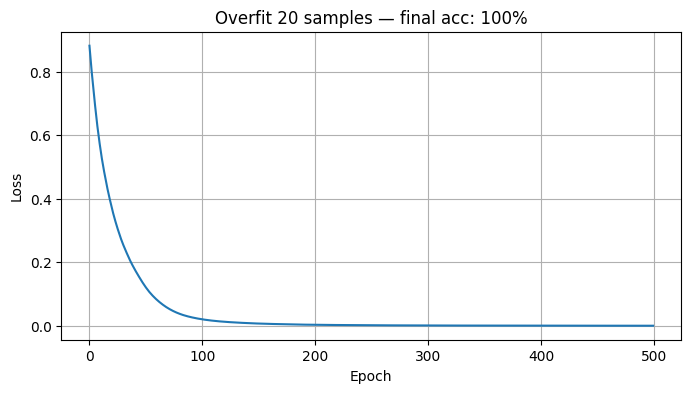

Final loss: 0.000311  |  Accuracy: 100.0%


In [3]:
np.random.seed(42)
config = NetworkConfig(layers=[30, 24, 24, 24, 2], activation='relu',
    loss='cross_entropy', output_activation='softmax', weights_initializer='heUniform')
net = Network(config)

n = 20
x = np.random.randn(n, 30)
y = np.zeros((n, 2))
y[np.arange(n), np.random.randint(0, 2, n)] = 1

opt = Adam(learning_rate=0.001)
losses = []
for _ in range(500):
    out = net.forward(x)
    losses.append(net.loss(y, out))
    nw, nb = net.backward(y)
    opt.update(net, nw, nb)

final = net.forward(x)
acc = np.mean(np.argmax(final, axis=1) == np.argmax(y, axis=1)) * 100

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title(f'Overfit {n} samples — final acc: {acc:.0f}%')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True)
plt.show()
print(f'Final loss: {losses[-1]:.6f}  |  Accuracy: {acc:.1f}%')